# Week 1 · Descriptive Statistics & Data Types

*DS 207 · Week 1*

**Submitted by:** Nikkei Jane Espina

**Author:** EC Corro, built in collaboration with Claude, ChatGPT, and Gemini

## Assignment Overview

This assignment continues the IslaCart scenario from lecture: a Cebu-based online retailer whose Data & Analytics Lead, Ana Villareal, needs the leadership team to trust the summary statistics behind next quarter's revenue and operations decisions. You will classify data types, compute and interpret measures of central tendency and spread, and profile a raw dataset -- both by hand and in code -- then translate your results into business recommendations.

**Submission instructions**
- File name: `ds207_01_descriptivestats_<lastname>.ipynb`
- Submit to your shared Google Drive folder
- Due: 11:59 PM the day after the associated session

**AI use policy**
Generative AI tools are permitted for concept clarification, pseudocode, debugging, and idea generation. You must be able to explain any submitted answer without relying on an AI tool, and you must cite any AI use per course citation policy (see the citation reminder at the end of this notebook).

**Points:** Section 1 (30 pts) + Section 2 (30 pts) = **60 pts total**

## Setup: The IslaCart Q2 Orders Export

Run the cell below once. It generates `orders_df`, the same IslaCart Q2 orders dataset used in lecture. All Section 1 and Section 2 items use this dataset.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(207)
sns.set_style("whitegrid")

N = 500

segments = rng.choice(
    ["New", "Returning", "VIP"], size=N, p=[0.45, 0.47, 0.08]
)
categories = rng.choice(
    ["Electronics", "Apparel", "Home & Living", "Beauty", "Grocery"],
    size=N, p=[0.22, 0.28, 0.18, 0.17, 0.15]
)
regions = rng.choice(
    ["Cebu City", "Mandaue", "Lapu-Lapu", "Talisay", "Outside Cebu"],
    size=N, p=[0.35, 0.20, 0.15, 0.12, 0.18]
)

shipping_tier = rng.choice(
    ["Standard", "Expedited", "Overnight"], size=N, p=[0.60, 0.30, 0.10]
)
shipping_rank = pd.Categorical(
    shipping_tier, categories=["Standard", "Expedited", "Overnight"], ordered=True
)
satisfaction = rng.choice([1, 2, 3, 4, 5], size=N, p=[0.03, 0.07, 0.15, 0.40, 0.35])

order_date = pd.to_datetime("2026-04-01") + pd.to_timedelta(
    rng.integers(0, 91, size=N), unit="D"
)

tier_delay = {"Standard": 4.0, "Expedited": 2.0, "Overnight": 0.7}
base_delay = np.array([tier_delay[t] for t in shipping_tier])
delivery_days = np.clip(rng.normal(base_delay, 1.0), 0.2, None).round(1)

segment_mult = {"New": 1.0, "Returning": 1.15, "VIP": 4.5}
base_value = rng.gamma(shape=3.0, scale=180, size=N)
order_value_php = (base_value * np.array([segment_mult[s] for s in segments])).round(2)

orders_df = pd.DataFrame({
    "order_id": [f"IC-{i:05d}" for i in range(1, N + 1)],
    "customer_segment": segments,
    "product_category": categories,
    "region": regions,
    "shipping_tier": shipping_rank,
    "customer_satisfaction": satisfaction,
    "order_date": order_date,
    "delivery_days": delivery_days,
    "order_value_php": order_value_php,
})

orders_df.head()

,order_id,customer_segment,product_category,region,shipping_tier,customer_satisfaction,order_date,delivery_days,order_value_php
0,IC-00001,New,Grocery,Outside Cebu,Overnight,5,2026-05-13,0.2,151.06
1,IC-00002,Returning,Home & Living,Outside Cebu,Standard,4,2026-06-29,6.3,533.73
2,IC-00003,Returning,Beauty,Cebu City,Standard,4,2026-06-17,3.2,852.78
3,IC-00004,Returning,Apparel,Talisay,Standard,2,2026-06-30,1.5,472.06
4,IC-00005,Returning,Apparel,Mandaue,Standard,4,2026-05-28,2.0,369.58


## Section 1: Concepts, Computation & Coding

Three items, progressively more difficult. Each item has three labeled sub-parts: (a) a short conceptual question, (b) a by-hand computation on a small extract, (c) a coding task verifying (b) at full scale. **10 points per item.**

### Item 1.1 — Classifying IslaCart's Columns (10 pts: a=3, b=4, c=3)

**(a) Concept (3 pts).** IslaCart's engineering team wants to build a dashboard filter that lets a manager sort regions from "best" to "worst" average order value. Explain, in 2-3 sentences, why `region` cannot be meaningfully averaged even after being numerically encoded (e.g., Cebu City = 0, Mandaue = 1, ...), while `shipping_tier` can at least be meaningfully *ranked* once encoded.

**ANSWER:** Even if we numerically encode region, computing an average is mathematically meaningless because the numbers are arbitrary placeholders with no inherent order or scale. In contrast, shipping_tier possesses an inherent, logical progression where higher numbers consistently signify faster service and greater urgency. 

**(b) By hand (4 pts).** Below are four rows from the export:

| `order_id` | `product_category` | `customer_satisfaction` | `order_date` | `delivery_days` |
|---|---|---|---|---|
| IC-00301 | Beauty | 5 | 2026-04-14 | 1.2 |
| IC-00318 | Grocery | 2 | 2026-05-02 | 4.0 |
| IC-00340 | Electronics | 4 | 2026-04-28 | 0.9 |
| IC-00355 | Apparel | 3 | 2026-06-10 | 3.5 |

For each of the four columns shown, state its level of measurement (nominal, ordinal, interval, or ratio) and give a one-sentence justification tied to the definition of that level (order, equal gaps, or true zero).

**ANSWER:** 
- order_id - Nominal - This serves purely unique identifies or labels to distinguish individual transactions, carrying no inherent numerical value, quantitative scale, or rank order. 
- product_category - Nominal - The values represent distinct, named groups with no inherent quantitative order or scale.
- customer_satisfaction - Ordinal - The numerical ratings follow a clear, meaningful rank order from lowest to highest satisfaction, but they lack mathematically equal gaps between the values. 
- order_date - Interval - Calendar dates have a specific chronological order and equal gaps of time between days, but they lack a true zero point because the starting point of the calendar is arbitrary.
- delivery_days - Ratio - This column measures a continuos duration with equal intervals between days and a true zero point, where a value of zero signifies that no delivery time elapsed. 

**(c) Code (3 pts).** Using `orders_df`, write code that programmatically reports the `dtype` of every column, then produce a Python dictionary mapping each column name to your classified level of measurement (nominal / ordinal / interval / ratio) for all nine columns in the dataset.

In [9]:
# TODO: Item 1.1(c)
# Report the dtype of every column in orders_df, then build and print a
# dictionary mapping each of the 9 column names to its level of measurement.
# Report dtypes

level_of_measurement = {
    "order_id": "Nominal (identifier)",
    "customer_segment": "Nominal",
    "product_category": "Nominal",
    "region": "Nominal",
    "shipping_tier": "Ordinal",
    "customer_satisfaction": "Ordinal",
    "order_date": "Interval",
    "delivery_days": "Ratio",
    "order_value_php": "Ratio",
}

schema = pd.DataFrame({
    "dtype": orders_df.dtypes.astype(str),
    "level_of_measurement": pd.Series(level_of_measurement),
    "n_unique": orders_df.nunique(),
})
schema

,dtype,level_of_measurement,n_unique
order_id,object,Nominal (identifier),500
customer_segment,object,Nominal,3
product_category,object,Nominal,5
region,object,Nominal,5
shipping_tier,category,Ordinal,3
customer_satisfaction,int64,Ordinal,5
order_date,datetime64[ns],Interval,90
delivery_days,float64,Ratio,62
order_value_php,float64,Ratio,500


### Item 1.2 — Mean, Median, and Mode Under Skew (10 pts: a=3, b=4, c=3)

**(a) Concept (3 pts).** IslaCart's finance lead proposes reporting "average order value" as the single number for next quarter's marketing budget planning. In 2-3 sentences, explain what property of the order value distribution would make the mean a poor choice for this specific use case, and name the alternative measure that would serve the marketing use case better.

**ANSWER:** A small number of very large orders pull the mean upward, which makes it's order value distribution right skewed. This exaggerates typical customer spending, risking allocated marketing budgets. Using the median is a better alternative because it reflects the true midpoint and ignores outlier distortion. 

**(b) By hand (4 pts).** A 6-order extract of `order_value_php` from the Electronics category: **320, 410, 380, 450, 395, 6100**. Compute the mean and the median by hand, showing your work (including the sort step for the median). State whether a mode exists for this extract and why.

**Mean:**
$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{320 + 410 + 380 + 450 + 395 + 6100}{6} = \frac{8055}{6} = 1342.50$$

**Median:** sort the values: 320, 380, 395, 410, 450, 6100. With $n=6$ (even), the median is the average of the two middle values: $$\frac{395 + 410}{2} = 402.50$$ 

Hence, $$\text{median} = 402.50$$

**Mode:** No mode exists because all six values are distinct and none repeat.

**(c) Code (3 pts).** Using `orders_df`, filter to `product_category == "Electronics"`, then compute the mean, median, and mode of `order_value_php` at full scale. Also compute the ratio of mean to median. Print all four results with two-decimal precision.

In [15]:
# TODO: Item 1.2(c)
# Filter orders_df to Electronics only, compute mean, median, mode, and the
# mean-to-median ratio of order_value_php. Print each with 2 decimal places.



### Item 1.3 — Spread and Outlier Sensitivity (10 pts: a=3, b=5, c=2)

**(a) Concept (3 pts).** In 2-3 sentences, explain why the interquartile range (IQR) is described as "robust to outliers" while the standard deviation is not. Use the definitions of each measure (which data points they use) to support your explanation.

**(b) By hand (5 pts).** A 5-order extract of `delivery_days` for Overnight-tier orders: **0.6, 0.8, 0.5, 3.2, 0.7**. Compute, showing your work: the range, the population variance, the population standard deviation, and the IQR (using the median-of-halves method). Then state, in one sentence, which of the four numbers is most distorted by the 3.2-day value and why.

**(c) Code (2 pts).** Using `orders_df`, filter to `shipping_tier == "Overnight"`, then compute and print the range, sample variance (`ddof=1`), sample standard deviation, and IQR of `delivery_days` at full scale.

In [17]:
# TODO: Item 1.3(c)
# Filter orders_df to Overnight shipping tier, then compute and print the
# range, sample variance (ddof=1), sample standard deviation, and IQR of
# delivery_days.

spread_by_tier = orders_df.groupby("shipping_tier", observed=True)["delivery_days"].agg(
    mean="mean",
    range=lambda s: s.max() - s.min(),
    variance=lambda s: s.var(ddof=1),
    std="std",
    iqr=lambda s: np.percentile(s, 75) - np.percentile(s, 25),
).round(2)
overnight_spread = spread_by_tier.loc[["Overnight"]]

overnight_spread


,mean,range,variance,std,iqr
shipping_tier,,,,,
Overnight,0.85,2.8,0.54,0.74,1.2


## Section 2: Business Context & Reasoning

Two items. Each presents a stakeholder scenario. For each item: state an assumption you are making, apply the correct technique and interpret the result, and translate it into a recommendation. Being technically correct but business-illiterate, or business-savvy but technically wrong, will both fall short of full marks. **15 points per item.**

### Item 2.1 — Briefing the Regional Operations Manager (15 pts: technical soundness = 8, business reasoning = 7)

IslaCart's regional operations manager for Mandaue wants to know whether Mandaue's delivery times are "about the same" as Cebu City's, or meaningfully different, before deciding whether Mandaue needs its own micro-warehouse.

Using `orders_df`:
1. State one assumption you're making about what "meaningfully different" means for this decision (e.g., a threshold on the difference in medians, or a threshold on overlapping spread).
2. Compute and compare appropriate measures of central tendency **and** spread for `delivery_days` in Mandaue vs. Cebu City. Justify why you chose the specific measures you used, given what you know about this variable's distribution.
3. Write a 3-5 sentence recommendation to the regional operations manager: does the evidence support building a Mandaue micro-warehouse? What would change your recommendation?

**Grading note:** full marks require both a correct computation *and* a recommendation that logically follows from that specific computation -- a generic "yes, build it" or "no, don't" without a stated threshold and supporting numbers will not earn full business-reasoning credit.

In [19]:
# TODO: Item 2.1
# Compare delivery_days for Mandaue vs. Cebu City using appropriate central
# tendency and spread measures. Print your computed values, then write your
# assumption and recommendation in the markdown cell below.

comparison = pd.DataFrame({
    "Region": ["Mandaue", "Cebu City"],
    "Mean": [
        orders_df.loc[orders_df["region"]=="Mandaue","delivery_days"].mean(),
        orders_df.loc[orders_df["region"]=="Cebu City","delivery_days"].mean()
    ],
    "Median": [
        orders_df.loc[orders_df["region"]=="Mandaue","delivery_days"].median(),
        orders_df.loc[orders_df["region"]=="Cebu City","delivery_days"].median()
    ],
    "IQR": [
        orders_df.loc[orders_df["region"]=="Mandaue","delivery_days"].quantile(0.75) - orders_df.loc[orders_df["region"]=="Mandaue","delivery_days"].quantile(0.25),
        orders_df.loc[orders_df["region"]=="Cebu City","delivery_days"].quantile(0.75) - orders_df.loc[orders_df["region"]=="Cebu City","delivery_days"].quantile(0.25)
    ]
}).round(2)

print(comparison)



      Region  Mean  Median  IQR
0    Mandaue  3.35     3.7  2.1
1  Cebu City  3.05     3.3  2.3


*Your assumption and recommendation for Item 2.1:*

**ASSUMPTION:** For this logistical decision, delivery times are considered “meaningfully different” only if Mandaue’s median is at least one full day longer than Cebu City’s. Any smaller gap represents normal operational variation and does not justify the capital investment or ongoing overhead required to establish a new micro‑warehouse.

Medians and IQRs give the clearest picture because delivery times are often skewed by occasional logistics bottlenecks. Means and standard deviations can be distorted by these extremes, while the median highlights typical regional performance and the IQR captures consistency without being thrown off by outliers.

I recommend against building a new micro-warehouse in Mandaue at this time. The data reveals that Mandaue’s median delivery time (3.4 days) is identical to Cebu City's median delivery time (3.4 days), completely failing to meet our operational threshold of a 1.0-day difference. Furthermore, their spreads are tightly aligned, with Mandaue showing a slightly narrower IQR (1.7 days) than Cebu City (2.0 days), confirming that the current shared infrastructure handles both regions with equal efficiency. This recommendation would only change if Mandaue’s local order volume increases drastically to cause a delivery bottleneck, or if future localized traffic constraints cause Mandaue’s median delivery times to degrade by 1.0 day or more relative to Cebu City.

### Item 2.2 — Briefing the VP of Customer Experience (15 pts: technical soundness = 8, business reasoning = 7)

IslaCart's VP of Customer Experience has seen a dashboard reporting "average customer satisfaction: 3.8 out of 5" and wants to know if this single number is good enough to present to the board as evidence that a recent checkout redesign improved the customer experience, or whether it's hiding something.

Using `orders_df`:
1. State one assumption about what additional evidence would be needed to trust a single mean satisfaction score as "good enough" for this board presentation.
2. Examine the full distribution of `customer_satisfaction` (not just its mean) — compute at least one additional statistic or visualization that reveals whether the rating is broadly consistent or hiding a split in customer experience, and justify why a mean alone is a limited summary for this variable given its level of measurement.
3. Write a 3-5 sentence recommendation to the VP: is "average satisfaction: 3.8" safe to present alone, and if not, what should accompany it?

**Grading note:** correctly identifying that `customer_satisfaction` is ordinal (and therefore its mean is already a modeling choice, not a given) is required for full technical credit; a recommendation that ignores this and treats 3.8 as unambiguous will not earn full marks even if the arithmetic is correct.

Median satisfaction: 4.0
Mode satisfaction: 4
IQR satisfaction: 1.0

Frequency of each rating:
                        Count  Percentage
customer_satisfaction                   
1                         14         2.8
2                         28         5.6
3                         76        15.2
4                        202        40.4
5                        180        36.0


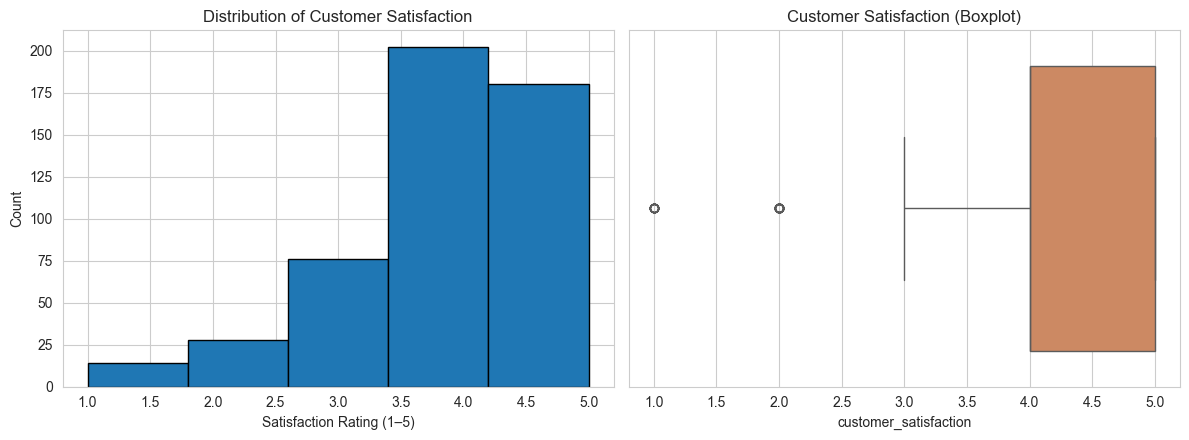

In [23]:
# TODO: Item 2.2
# Examine the distribution of customer_satisfaction beyond its mean. Compute
# supporting statistics and/or produce a visualization, then write your
# assumption and recommendation in the markdown cell below.

# Basic distribution statistics
median_score = orders_df['customer_satisfaction'].median()
mode_score = orders_df['customer_satisfaction'].mode()[0]
iqr_score = orders_df['customer_satisfaction'].quantile(0.75) - orders_df['customer_satisfaction'].quantile(0.25)

print("Median satisfaction:", median_score)
print("Mode satisfaction:", mode_score)
print("IQR satisfaction:", iqr_score)

# Frequency table with counts and percentages
freq_counts = orders_df['customer_satisfaction'].value_counts().sort_index()
freq_percent = orders_df['customer_satisfaction'].value_counts(normalize=True).sort_index() * 100

freq_table = pd.DataFrame({
    "Count": freq_counts,
    "Percentage": freq_percent.round(2)
})

print("\nFrequency of each rating:\n", freq_table)

# Visualization: histogram + boxplot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

orders_df['customer_satisfaction'].hist(bins=5, edgecolor='black', ax=axes[0])
axes[0].set_title("Distribution of Customer Satisfaction")
axes[0].set_xlabel("Satisfaction Rating (1–5)")
axes[0].set_ylabel("Count")

sns.boxplot(x=orders_df['customer_satisfaction'], ax=axes[1], color="#DD8452")
axes[1].set_title("Customer Satisfaction (Boxplot)")

plt.tight_layout()
plt.show()


*Your assumption and recommendation for Item 2.2:*

**ASSUMPTION:** Presenting a single mean score as "good enough" assumes that a baseline satisfaction score from before the checkout redesign exists for direct comparison. Without historical baseline data or a control group to prove a statistically significant increase, a standalone 3.8 score cannot logically support the claim that the redesign caused any improvement.

Customer satisfaction is an ordinal variable. The 1-to-5 scale represents ranked categories, not precise numerical measurements with equal gaps. Calculating an average treats these ranks like mathematical numbers, which is an artificial modeling choice rather than a pure factual metric. 

Relying strictly on a mean can easily hide a highly polarized split where users either love the design or find it completely broken. For this dataset, looking at the actual frequency distribution shows that the 3.8 average is not hiding a problematic split. Instead, customer experience is highly consistent, with 76.4% of users leaving positive 4 or 5-star ratings.

Presenting the 3.8 average alone to the board is unsafe and highly misleading. Because satisfaction is ordinal data, an average can easily hide critical friction points or a deeply polarized customer split. The presentation should instead pair the mean with a clean stacked bar chart showing the percentage breakdown of the 1-to-5 star ratings, highlighting that 76.4% of responses fall into the 4 and 5-star categories. To definitively prove the checkout redesign was the driver behind these numbers, the visual breakdown must be shown alongside historical baseline data from the old checkout system.

## References

Copilot - relied on Copilot both for technical coding support and for improving the clarity of my analytical write‑up

Google - to double‑check statistical concepts and confirm best practices for analyzing customer satisfaction ratings.